# Load and explore data

In [5]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
housing = fetch_california_housing(as_frame=True)

In [4]:
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [14]:
data = df[["MedInc","MedHouseVal"]]
data.describe()


,MedInc,MedHouseVal
count,20640.000000,20640.000000
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

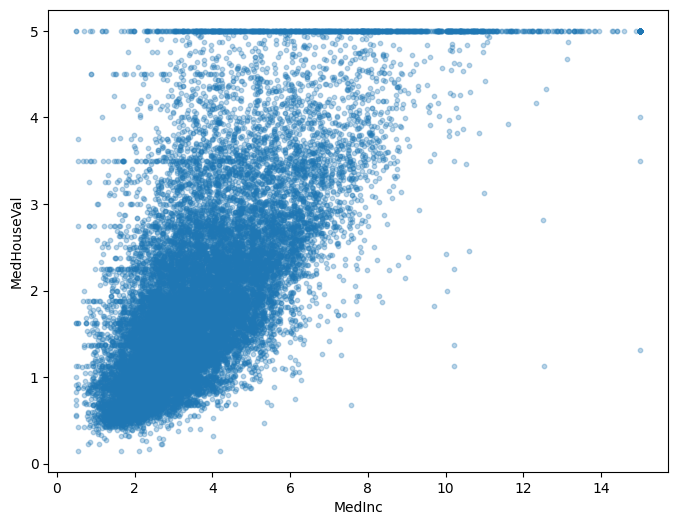

In [17]:
data.plot(kind="scatter", x="MedInc", y="MedHouseVal", alpha=0.3, s=10, figsize=(8,6))

## Observations from the raw scatter plot

- **Cap at MedHouseVal = 5.0**: There's a dense horizontal line of points sitting exactly 
  at y = 5.0. This isn't a natural data pattern — the dataset caps median house value at 
  $500,000, so any district actually worth more than that gets clipped down to exactly 5.0. 
  This means the true relationship for high-value districts is hidden, and it could pull 
  my regression line in a way that doesn't reflect reality at the high end.

- **Dense cluster, x: 0–8, y: 0–4.5**: The majority of the data sits in a cluster of low-to-mid 
  income (roughly 0–8) paired with low-to-mid house values (roughly 0–4.5). Above that, points 
  get sparser and more spread out, suggesting few districts have very high income. This looks 
  like a right-skewed distribution rather than an even spread across the income range.

- **Implication for modeling**: Since most of my data is concentrated in a lower range, a small 
  number of high-income outliers could have outsized influence on my learned slope/intercept 
  once I start training.

## Linear Regression Equation
Given: ŷ = w·x + b
- y hat is what we are trying to predict which is the Median House Value, while x is the Median Income
- w is our slope which tells us how much y hat changes for every 1 unit increase in x
- b is our bias which tells us what would the model predict if the median income was 0?

# Preprocessing

In [18]:
from sklearn.model_selection import train_test_split
X = df["MedInc"]
y = df["MedHouseVal"]
trainX, valX, trainY, valY = train_test_split(X,y, test_size=0.25, random_state=8)
print(trainX.shape, valX.shape, trainY.shape, valY.shape)

(15480,) (5160,) (15480,) (5160,)


# Implementing loss functions manually

In [27]:
import numpy as np
dummy_true = np.array([3, 5, 2, 10])
dummy_pred = np.array([2.5, 5.5, 1, 2])
def mse(y_true,y_pred):
    return np.mean((y_true - y_pred) ** 2)
def mae(y_true,y_pred):
    return np.mean(np.abs(y_true - y_pred))
def rmse(y_true,y_pred):
    return np.sqrt(mse(y_true,y_pred))

print("MAE:", mae(dummy_true, dummy_pred))
print("MSE:", mse(dummy_true, dummy_pred))
print("RMSE:", rmse(dummy_true, dummy_pred))

MAE: 2.5
MSE: 16.375
RMSE: 4.046603514059662


# Implement and derive gradients

## Gradients

Starting from MSE = (1/n) * Σ (y - ŷ)², where ŷ = w·x + b

**Gradient with respect to w:**
∂MSE/∂w = -(2/n) * Σ (y - ŷ) · x

**Gradient with respect to b:**
∂MSE/∂b = -(2/n) * Σ (y - ŷ)

These tell us the direction and magnitude to adjust w and b to reduce loss.
In gradient descent, we update:
w = w - learning_rate * ∂MSE/∂w
b = b - learning_rate * ∂MSE/∂b

In [ ]:
def compute_gradients(x, y, w, b):
    y_pred = (w*x) + b
    error = y - y_pred
    dw = -2 * np.mean(error*x)        # -(2/n) * sum(error * x)
    db =  -2 * np.mean(error)         # -(2/n) * sum(error)
    return dw, db

x_test = np.array([1, 2, 3])
y_test = np.array([3, 5, 7])

dw, db = compute_gradients(x_test, y_test, w=0, b=0)
print("dw:", dw, "db:", db)

dw: -22.666666666666668 db: -10.0


# Mini-batch SGD training loop

In [29]:
# Set up parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.03
epochs = 50
batch_size = 50

# Track loss
loss_list = []

In [ ]:
# shuffle
indicesX = np.arange(len(trainX))
indicesY = np.arange(len(trainY))
np.random.shuffle(indicesX)
np.random.shuffle(indicesY)